In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [3]:
# Load the data
df = pd.read_csv('../../data/01_raw/raw_renewal_calls.csv')
df.columns = df.columns.str.lower().str.strip()

df.head()

/var/folders/6q/3_ys7c717hz_scqx9xw7q35w0000gn/T/ipykernel_3679/3963434455.py:2: DtypeWarning: Columns (4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../data/01_raw/raw_renewal_calls.csv')


,call_id,call_direction,co_ref,call_date,churn_category,complaint_category,customer_reaction_category,agent_renewal_pitch_category,customer_renewal_response_category,agent_response_category,...,customer_response,desire_to_cancel,discount_offered,justification_category,reason_for_renewal_category,agent_response_to_cancel_category,argument_that_convinced_customer_to_stay_category,analysed_call,call_number,call_year
0,5.950000e+11,Outbound,UB0899,29-01-2025,NaN,NaN,Not Mentioned,Discussion / Introduction / Inquiry,Discount and Offer,Discount and Offer,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,3,2025
1,5.970000e+11,OUT_BOUND,HN5141,26-02-2025,NaN,NaN,NaN,Price and Cost,Agreement,Customer Communication,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,2,2025
2,5.950000e+11,Outbound,BP5009,24-01-2025,NaN,NaN,NaN,Expiration / Due,Agreement,Accreditation and Certification,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,1,2025
3,6.520000e+11,OUT_BOUND,XP8119,09-06-2025,NaN,NaN,NaN,Auto / Automatic,Agreement,Accreditation and Certification,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,1,2025
4,5.370000e+11,Outbound,ZL7978,20-08-2024,NaN,NaN,NaN,NaN,NaN,NaN,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,28,2024


In [4]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186534 entries, 0 to 186533
Data columns (total 41 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   call_id                                            186534 non-null  float64
 1   call_direction                                     186534 non-null  object 
 2   co_ref                                             179149 non-null  object 
 3   call_date                                          186534 non-null  object 
 4   churn_category                                     7902 non-null    object 
 5   complaint_category                                 19008 non-null   object 
 6   customer_reaction_category                         23085 non-null   object 
 7   agent_renewal_pitch_category                       53738 non-null   object 
 8   customer_renewal_response_category                 54312 non-null   object

,call_id,call_direction,co_ref,call_date,churn_category,complaint_category,customer_reaction_category,agent_renewal_pitch_category,customer_renewal_response_category,agent_response_category,...,customer_response,desire_to_cancel,discount_offered,justification_category,reason_for_renewal_category,agent_response_to_cancel_category,argument_that_convinced_customer_to_stay_category,analysed_call,call_number,call_year
count,1.865340e+05,186534,179149,186534,7902,19008,23085,53738,54312,53980,...,88721,88718,88721,13080,16135,4927,1818,88744.0,186534.000000,186534.000000
unique,NaN,4,36303,467,18,22,13,18,20,20,...,4,474,3,30,23,22,17,NaN,NaN,NaN
top,NaN,Outbound,XG1277,02-04-2024,Unnecessary / Not needed,Price Increase / Rise and Value,Not Mentioned,Expiration / Due,Agreement,Payment,...,Neutral,Renewed,No,Other (misidentified),Incentive / support offered,Incentive / support offered,Financial Incentives / Cost-Effectiveness,NaN,NaN,NaN
freq,NaN,83493,221,692,1689,3350,10829,13412,10684,10308,...,58787,40367,81357,1493,4816,1174,457,NaN,NaN,NaN
mean,5.964301e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,150.579926,2024.599070
std,7.543269e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,824.314463,0.598115
min,1.930000e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.000000,2024.000000
25%,5.130000e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.000000,2024.000000
50%,5.950000e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,4.000000,2025.000000
75%,6.790000e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,10.000000,2025.000000


In [5]:
df.isnull().sum().sort_values(ascending=False)

unnamed: 20                                          186534
argument_that_convinced_customer_to_stay_category    184716
agent_response_to_cancel_category                    181607
churn_category                                       178632
justification_category                               173454
reason_for_renewal_category                          170399
complaint_category                                   167526
customer_reaction_category                           163449
agent_renewal_pitch_category                         132796
agent_response_category                              132554
customer_renewal_response_category                   132222
other_complaint                                      102202
serious_complaint                                    102201
membership_renewal_decision                           99960
competitor_benefits_mentioned                         99956
renewal_impact_due_to_price_increase                  98529
discount_or_waiver_requested            

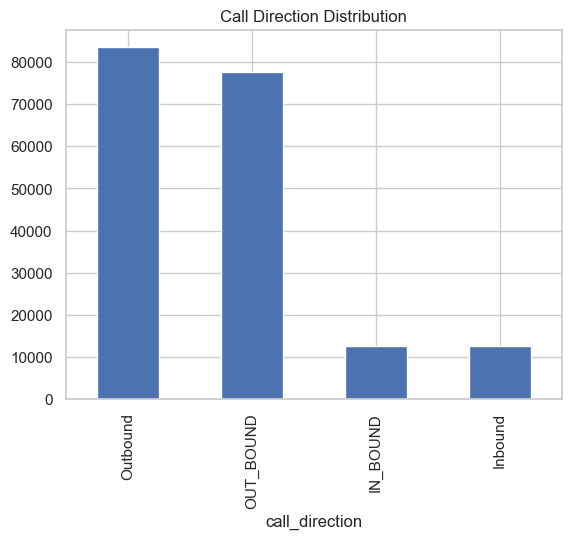

In [6]:
df['call_direction'].value_counts().plot(kind='bar')
plt.title("Call Direction Distribution")
plt.show()

In [10]:
num_cols = [
    'explicit_switching_intent',
    'desire_to_cancel',
    'serious_complaint',
    'discussion_on_price_increase',
    'discount_or_waiver_requested'
]

df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

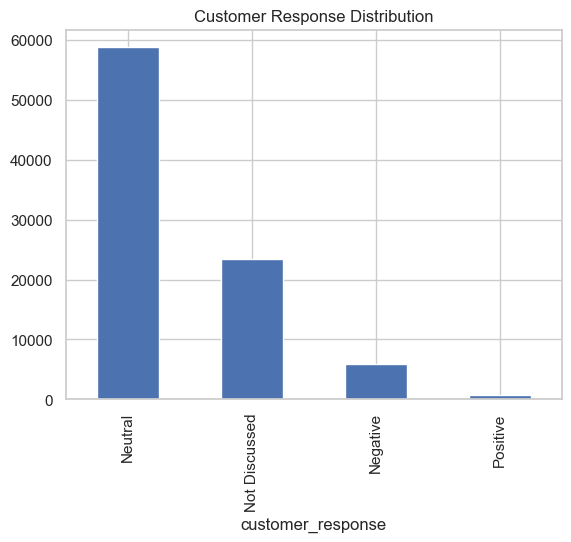

In [12]:
df['customer_response'].value_counts().head(10).plot(kind='bar')
plt.title("Customer Response Distribution")
plt.show()

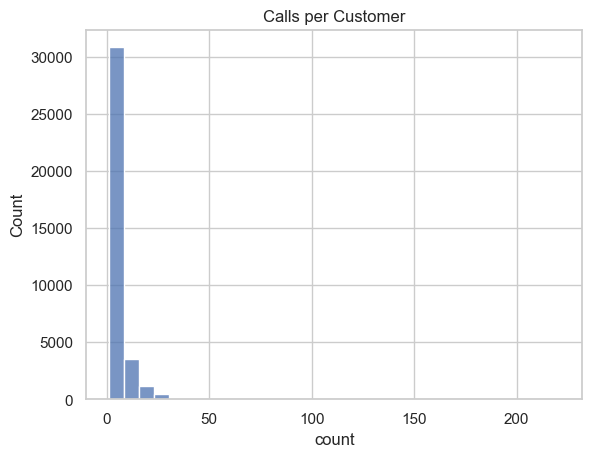

In [13]:
calls_per_user = df['co_ref'].value_counts()

sns.histplot(calls_per_user, bins=30)
plt.title("Calls per Customer")
plt.show()

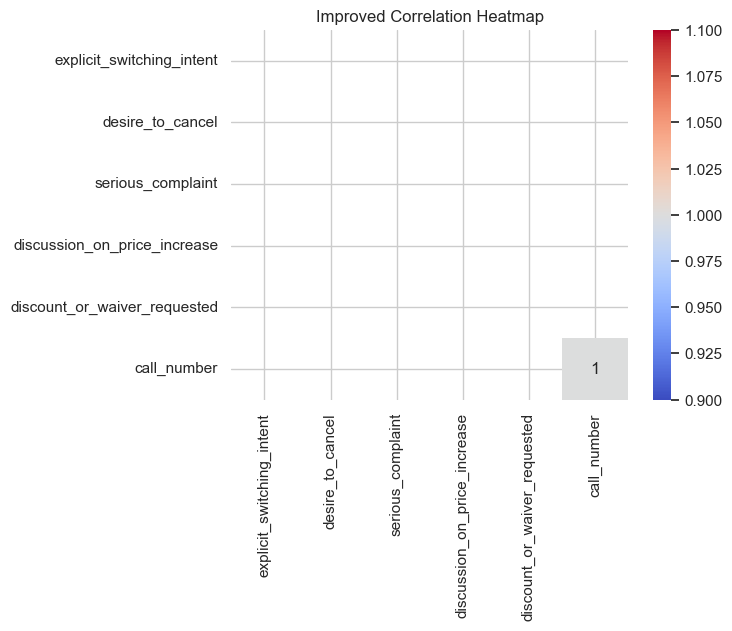

In [17]:
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Improved Correlation Heatmap")
plt.show()